# Data Conversion Script

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exploration of the database
Notes of the exploration:
- Patients 3, 4, 6 and 12 angles of the knee are inverted. The inverse of the angles have to be done.
- Patient 7 has a mixture of positive and negative angles at the knee, so an inversion has to be done, but not by 180º.

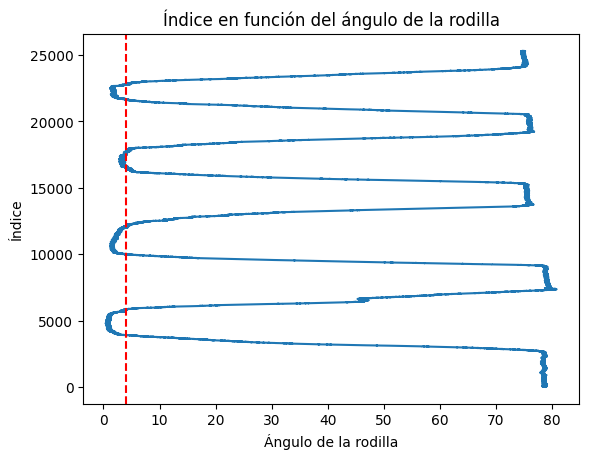

In [18]:
df = pd.read_csv('C:/Users/alvar/Desktop/Discrete_validation/Data_raw/14gait.txt', skiprows=3, delim_whitespace= True, header=None)

df.columns = ['mV', 'Knee angle']

angulos = df['Knee angle']

fig, ax = plt.subplots()

# Intercambia los argumentos en la función plot
ax.plot(angulos.values, angulos.index)

ax.axvline(x=4, color='r', linestyle='--')
#ax.axvline(x=54, color='r', linestyle='--')

# Establece los títulos de la gráfica y los ejes
ax.set_title('Índice en función del ángulo de la rodilla')
ax.set_xlabel('Ángulo de la rodilla')
ax.set_ylabel('Índice')

# Muestra la gráfica
plt.show()


## Inversion of patients
For patient 3 we have to add 80 degrees, but for patient 6 we have to add 100 degrees.

For patient 7 we have to add 60 degrees.

For patients 4 and 12 we have to add 85 degrees.

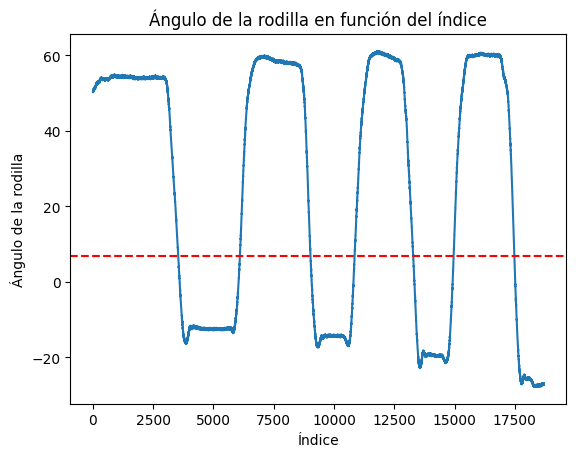

In [16]:
df = pd.read_csv('C:/Users/alvar/Desktop/Discrete_validation/Data_raw/12gait.txt', skiprows=3, delim_whitespace= True, header=None)

df.columns = ['mV', 'Knee angle']

angulos = df['Knee angle'] + 60

fig, ax = plt.subplots()

ax.plot(angulos.index, angulos.values)

ax.axhline(y=7, color='r', linestyle='--')
#ax.axhline(y=70, color='r', linestyle='--')

# Establece los títulos de la gráfica y los ejes
ax.set_title('Ángulo de la rodilla en función del índice')
ax.set_xlabel('Índice')
ax.set_ylabel('Ángulo de la rodilla')

# Muestra la gráfica
plt.show()

## List of names and angles

In [5]:
in_route = 'C:/Users/alvar/Desktop/Discrete_validation/Data_raw'
out_route = 'C:/Users/alvar/Desktop/Discrete_validation/Results'

if not os.path.exists(out_route):
    os.makedirs(out_route)

file_names = ['1gait.txt', '2gait.txt', '3gait.txt', '4gait.txt', '5gait.txt', '6gait.txt', '7gait.txt', '8gait.txt', '9gait.txt', 
'10gait.txt', '11gait.txt', '12gait.txt', '13gait.txt', '14gait.txt']

angles = [28, 28, 7, 9, 6, 19, 22, 9, 14, 6.5, 6.5, 15, 8, 6]
swing_marker_angles = [65, 65, 59, 75, 55, 70, 45, 54, 54, 54, 54, 65, 54, 54]

## Main Code

In [6]:
x = 0

for file in file_names:
    angle = angles[x]
    swing_marker_angle = swing_marker_angles[x]
    x += 1
    new_route_out = out_route + '/Patient_' + str(x)
    if not os.path.exists(new_route_out):
        os.makedirs(new_route_out)
    
    print('Analyzing ' + file)

    df = pd.read_csv(in_route + '/' + file, skiprows=3, delim_whitespace=True, header=None)
    df.columns = ['Vastus medialis (mV)', 'Knee angle']
    
    if file == '3gait.txt':
        df['Knee angle'] = df['Knee angle'] + 80
    elif file == '4gait.txt' or file == '12gait.txt':
        df['Knee angle'] = df['Knee angle'] + 85
    elif file == '6gait.txt':
        df['Knee angle'] = df['Knee angle'] + 100
    elif file == '7gait.txt':
        df['Knee angle'] = df['Knee angle'] + 60

    # Crear una nueva columna que indica dónde está el valor que buscas
    df['Indicator'] = df['Knee angle'] <= angle

    # Calcular los grupos de filas entre los valores que buscas
    df['Group'] = df['Indicator'].cumsum()

    # Ahora puedes obtener cada tabla individual
    swing_phases = [group for _, group in df.groupby('Group')]

    filter_column = 'Knee angle'

    # Filtrar las tablas
    filtered_swing = [table for table in swing_phases if table[filter_column].max() > swing_marker_angle]

    stance_phases = []
    for i in range(len(filtered_swing)-1):
        stance_phases.append(df.iloc[filtered_swing[i].index[-1]+1 : filtered_swing[i+1].index[0]].copy())
    stance_phases.append(df.iloc[filtered_swing[-1].index[-1]+1:].copy())
    

    final_swing_subtables = []
    for subtable in filtered_swing:
        if not subtable.empty:
            first_index = subtable.index[0]
            last_index = subtable.index[-1]
            
            final_swing_subtable = df.loc[first_index:last_index, 'Vastus medialis (mV)'].copy().to_frame()
            final_swing_subtable['Time (ms)'] = np.arange(1, len(final_swing_subtable) + 1)
            final_swing_subtable['Time (ms)'] = final_swing_subtable['Time (ms)']/1000
            
            final_swing_subtables.append(final_swing_subtable)
    
    final_stance_subtables = []
    for subtable in stance_phases:
        if not subtable.empty:
            first_index = subtable.index[0]
            last_index = subtable.index[-1]
            
            final_stance_subtable = df.loc[first_index:last_index, 'Vastus medialis (mV)'].copy().to_frame()
            final_stance_subtable['Time (ms)'] = np.arange(1, len(final_stance_subtable) + 1)
            final_stance_subtable['Time (ms)'] = final_stance_subtable['Time (ms)']/1000

            final_stance_subtables.append(final_stance_subtable)
    
    for i, subtable in enumerate(final_swing_subtables):
        if i > 0:
            subtable.reset_index(drop=True, inplace=True)

            subtable.to_csv(f'{new_route_out}/Swing_{i}.txt', sep='\t', index=False, header=True)

    for i, subtable in enumerate(final_stance_subtables):
        subtable.reset_index(drop=True, inplace=True)
        
        subtable.to_csv(f'{new_route_out}/Stance_{i+1}.txt', sep='\t', index=False, header=True)

Analyzing 1gait.txt
Analyzing 2gait.txt
Analyzing 3gait.txt
Analyzing 4gait.txt
Analyzing 5gait.txt
Analyzing 6gait.txt
Analyzing 7gait.txt
Analyzing 8gait.txt
Analyzing 9gait.txt
Analyzing 10gait.txt
Analyzing 11gait.txt
Analyzing 12gait.txt
Analyzing 13gait.txt
Analyzing 14gait.txt
